In [1]:
cd ../src/train_VAE/

/home/rfit/Telescope_Array/phd_work/src/train_VAE


In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import sklearn
import umap.umap_ as umap
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook
# for classifcator 
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay, recall_score, precision_score


In [3]:
import h5py as h5
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
data_path = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T_one_work.h5'

In [4]:
try:
    import importlib
    importlib.reload(pipline)
except NameError:
    import pipline

Using device: cuda


2026-04-02 01:14:00.094144: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775081640.110868   66293 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775081640.115899   66293 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775081640.128872   66293 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775081640.128900   66293 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775081640.128903   66293 computation_placer.cc:177] computation placer alr

In [5]:
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [26]:
config = 'config.yaml'
model = pipline.Pipline(config)
model.config['latent_dim'] = 8
exp = 'info_Transfoemr_MMD_0.05_KL_0.01'
chpt = f"/home/rfit/Telescope_Array/phd_work/Models/AutoEncoder/{exp}/best"
model.load_chpt(chpt)

['catboost_info', 'pipline.py', '__pycache__', 'show_loss.py', 'model_old.py', 'metric.py', 'loss_hist.png', 'runs', 'test_runs', 'datasets.py', 'phd_work', 'runs_tests', 'model.py', 'loss.py', 'tests', 'utils.py', 'init.sh', 'config.yaml', '__init__.py', 'for_temporary_work', '.ipynb_checkpoints']


Encoder has params: 783944 Decoder has params: 2055719
split_num 10000 <class 'int'>
Saving Path: /home/rfit/Telescope_Array/phd_work/Models/AutoEncoder/info_Transfoemr_MMD_0.05_KL_0.01_new_MMD2_MMD_KL_0
self.koef_KL tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.], device='cuda:0', dtype=torch.float64)
load True format. If it is 'FALSE' we worning


In [27]:
latent_list, recon__list, particles, all_loss = model.predict(model.val_loaders[0], 0)

  0%|          | 0/5194 [00:00<?, ?it/s]/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:139: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/torch/nn/modules/loss.py:520: UserWarning: Using a target size (torch.Size([150, 1])) that is different to the input size (torch.Size([150])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
  0%|          | 5/5194 [00:00<05:00, 17.29it/s]

100%|█████████▉| 5193/5194 [06:12<00:00, 13.07it/s]/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/torch/nn/modules/loss.py:520: UserWarning: Using a target size (torch.Size([92, 1])) that is different to the input size (torch.Size([92])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 5194/5194 [06:12<00:00, 13.96it/s]


In [28]:
latent_list_ph, recon__list_ph, particles_ph, all_loss_ph = model.predict(model.val_loaders[1], 1)

100%|█████████▉| 2428/2430 [02:41<00:00, 13.24it/s]/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/torch/nn/modules/loss.py:520: UserWarning: Using a target size (torch.Size([69, 1])) that is different to the input size (torch.Size([69])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 2430/2430 [02:41<00:00, 15.04it/s]


In [35]:
'''
mc_params (num_evs,10):
0. mc_event_num
1. mc_parttype (CORSIKA, 1 - gamma, 14 - proton, 5626 - Fe)
2. mc_corecounter, closest to core detector number
3. mc_E (for primaries other than photon energy is rescaled by 1/1.27, i.e. to proton FD energy scale)
4. mc_theta
5. mc_phi
6. mc_height_1st_inter, km
7. mc_xcore
8. mc_ycore
9. mc_border_distance, km 
'''
with h5.File(data_path,'r') as f:
    print('keys', list(f.keys()))
    test = f['test']
    keys = list(test.keys())
    mc_params = test['mc_params'][:]
mc_params.shape

keys ['norm_param', 'test', 'train', 'val']


(1143461, 10)

In [30]:
latent_list_ph.shape, latent_list.shape

(torch.Size([364419, 8]), torch.Size([779042, 8]))

In [36]:
ph_mc_params = mc_params[np.where(mc_params[:,1]==1)]
pr_mc_params = mc_params[np.where(mc_params[:,1]==14)]
pr_mc_params.shape, ph_mc_params.shape


((779042, 10), (364419, 10))

In [71]:
# Уникальные комбинации по колонкам 3, 4, 6 (E, theta, height_1st_inter) и группы индексов
cols = ph_mc_params[:, [4, 6]]
uvals, inv = np.unique(cols, axis=0, return_inverse=True)
# inv[i] — номер уникальной строки для i-й строки pr_mc_params
# Группы: для каждой уникальной комбинации — массив индексов в pr_mc_params
groups_by_346 = {i: {'ind': np.where(inv == i)[0],
                    'el_by_group': uvals[i],
                    'num': len(np.where(inv == i)[0])} for i in range(len(uvals))}
# Либо ключом сделать саму комбинацию (E, theta, height):
# groups_by_346 = {tuple(uvals[i]): np.where(inv == i)[0] for i in range(len(uvals))}
print(f"Уникальных комбинаций (4,6): {len(uvals)}, пример размера группы: {len(groups_by_346[0])}")

Уникальных комбинаций (4,6): 2139, пример размера группы: 3


In [72]:
groups_by_346

{0: {'ind': array([  1227,   3850,   7078,   9253,   9497,  10145,  10487,  12397,
          13459,  19757,  22307,  25969,  31837,  34794,  36693,  37155,
          39260,  40022,  42018,  42687,  43255,  45677,  50735,  53188,
          53604,  54699,  55885,  57319,  59604,  67275,  68241,  72182,
          75762,  78649,  81375,  82829,  86871,  87981,  90149,  92688,
          95128, 100624, 100759, 102822, 105571, 106891, 109949, 112006,
         114173, 114609, 114896, 115878, 118287, 118654, 121623, 121797,
         123583, 125153, 125376, 125793, 126496, 129669, 130150, 131080,
         131818, 132024, 132085, 132524, 134452, 135601, 136787, 137072,
         139688, 141478, 143918, 145220, 147254, 150430, 151796, 153524,
         153783, 155049, 158429, 158872, 158946, 162193, 162365, 164371,
         165009, 165598, 169781, 172733, 173745, 173756, 174726, 174939,
         176147, 180700, 190489, 190629, 192796, 193997, 195164, 195516,
         198313, 198884, 203369, 204203, 

In [73]:
n=5
top_15_group = {}
nums = []
for k,v in groups_by_346.items():
    nums.append(v['num'])
top_15_nums = sorted(nums) [-n:]
for k,v in groups_by_346.items():
    if v['num'] in top_15_nums:
        top_15_group[k] = v
len(top_15_group)

5

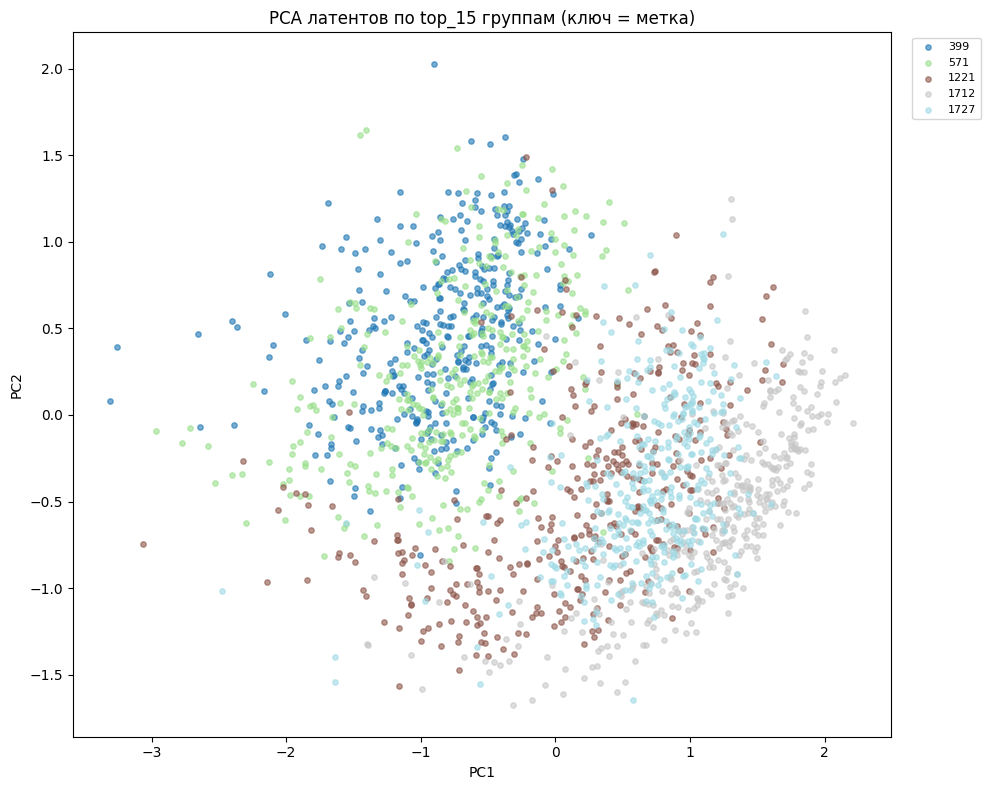

In [75]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Латенты по группам top_15 (ind — индексы в pr_mc_params, порядок совпадает с latent_list)
X_all = np.concatenate([latent_list_ph[v['ind']] for k, v in top_15_group.items()], axis=0)
reducer = PCA(n_components=2, random_state=42)
reducer.fit(latent_list_ph)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(top_15_group)))

for (key, val), color in zip(top_15_group.items(), colors):
    ind = val['ind']
    X_k = latent_list_ph[ind]
    X_2d = reducer.transform(X_k)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=[color], label=str(key), alpha=0.6, s=15)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA латентов по top_15 группам (ключ = метка)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# CatBoot Predict mc params

'''
mc_params (num_evs,10):

0. mc_event_num
1. mc_parttype (CORSIKA, 1 - gamma, 14 - proton, 5626 - Fe)
2. mc_corecounter, closest to core detector number
3. mc_E (for primaries other than photon energy is rescaled by 1/1.27, i.e. to proton FD energy scale)
4. mc_theta
5. mc_phi
6. mc_height_1st_inter, km
7. mc_xcore
8. mc_ycore
9. mc_border_distance, km 

'''

In [37]:
latent_list_pr = latent_list
latent_list_ph.shape, latent_list_pr.shape

(torch.Size([364419, 8]), torch.Size([779042, 8]))

In [38]:
pr_mc_params = mc_params[np.where(mc_params[:,1]==1)]
ph_mc_params = mc_params[np.where(mc_params[:,1]==14)]
ph_mc_params.shape, pr_mc_params.shape

((779042, 10), (364419, 10))

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
import numpy as np
import torch

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def train_catboost_for_metric(i, test_size=0.2, random_state=42, name = 'predict pr and ph', num=int(1e5)):
    """
    Обучает два CatBoostRegressor:
    - для протонов (latent_list_pr -> pr_mc_params[:, i])
    - для фотонов (latent_list_ph -> ph_mc_params[:, i])
    и возвращает модели и метрики.
    """
    # целевые значения
    y_pr = to_numpy(pr_mc_params)[:, i][:num]
    y_ph = to_numpy(ph_mc_params)[:, i][:num]

    # признаки (латенты)
    X_pr = to_numpy(np.stack(latent_list_pr))[:num]  # (N_pr, latent_dim)
    X_ph = to_numpy(np.stack(latent_list_ph))[:num]  # (N_ph, latent_dim)

    # train/test сплиты по отдельности для протонов и фотонов
    X_tr_pr, X_te_pr, y_tr_pr, y_te_pr = train_test_split(
        X_pr, y_pr, test_size=test_size, random_state=random_state
    )
    X_tr_ph, X_te_ph, y_tr_ph, y_te_ph = train_test_split(
        X_ph, y_ph, test_size=test_size, random_state=random_state
    )

    model_pr = CatBoostRegressor(
        depth=6,
        learning_rate=0.1,
        loss_function='RMSE',
        verbose=True,
        random_seed=random_state,
    )
    model_ph = CatBoostRegressor(
        depth=6,
        learning_rate=0.1,
        loss_function='RMSE',
        verbose=True,
        random_seed=random_state,
    )

    model_pr.fit(X_tr_pr, y_tr_pr)
    model_ph.fit(X_tr_ph, y_tr_ph)

    # качество на тесте
    pred_pr = model_pr.predict(X_te_pr)
    pred_ph = model_ph.predict(X_te_ph)

    metrics = {
        'pr': {
            'rmse': mean_squared_error(y_te_pr, pred_pr),
            'r2': r2_score(y_te_pr, pred_pr),
            'model': model_pr,
        },
        'ph': {
            'rmse': mean_squared_error(y_te_ph, pred_ph),
            'r2': r2_score(y_te_ph, pred_ph),
            'model': model_ph,
        },
    }
    f,ax = plt.subplots(1,3, figsize = (21,6))
    ax[0].scatter(y_te_pr, pred_pr, color = 'b', label = 'pr')
    ax[1].scatter(y_te_ph, pred_ph, color='orange', label = 'ph')


    ax[2].scatter(y_te_ph, pred_ph, color='orange', label = 'ph')
    ax[2].scatter(y_te_pr, pred_pr, color = 'b', label = 'pr')
    ax[0].plot(y_te_pr, y_te_pr, '--r', label = 'gold')
    ax[1].plot(y_te_pr, y_te_pr, '--r', label = 'gold')
    ax[2].plot(y_te_pr, y_te_pr, '--r', label = 'gold')
    ax[0].set_ylabel('predict')
    ax[1].set_ylabel('predict')
    ax[2].set_ylabel('predict')
    ax[0].set_xlabel('real')
    ax[1].set_xlabel('real')
    ax[2].set_xlabel('real')
    ax[0].grid()
    ax[1].grid()
    ax[2].grid()
    ax[0].legend()
    ax[1].legend()
    ax[2].legend()
    ax[1].set_title(name)
    return metrics

0:	learn: 78.5890932	total: 8.2ms	remaining: 8.19s
1:	learn: 78.5846183	total: 13.7ms	remaining: 6.83s
2:	learn: 78.5785553	total: 20.5ms	remaining: 6.81s
3:	learn: 78.5680690	total: 26.5ms	remaining: 6.61s
4:	learn: 78.5636282	total: 46ms	remaining: 9.14s
5:	learn: 78.5575544	total: 72ms	remaining: 11.9s
6:	learn: 78.5503635	total: 75.6ms	remaining: 10.7s
7:	learn: 78.5425042	total: 79.1ms	remaining: 9.81s
8:	learn: 78.5365214	total: 82.4ms	remaining: 9.07s
9:	learn: 78.5313000	total: 85.3ms	remaining: 8.45s
10:	learn: 78.5266606	total: 88.2ms	remaining: 7.93s
11:	learn: 78.5199709	total: 91.1ms	remaining: 7.5s
12:	learn: 78.5144374	total: 115ms	remaining: 8.76s
13:	learn: 78.5094016	total: 119ms	remaining: 8.35s
14:	learn: 78.5034223	total: 122ms	remaining: 7.98s
15:	learn: 78.4987503	total: 125ms	remaining: 7.69s
16:	learn: 78.4949502	total: 144ms	remaining: 8.31s
17:	learn: 78.4901138	total: 148ms	remaining: 8.07s
18:	learn: 78.4863624	total: 151ms	remaining: 7.78s
19:	learn: 78.48

{'pr': {'rmse': 6308.937745126704,
  'r2': -0.018214743930312416,
  'model': <catboost.core.CatBoostRegressor at 0x7fee8d7aa1f0>},
 'ph': {'rmse': 7854.307513204497,
  'r2': -0.016632962980818844,
  'model': <catboost.core.CatBoostRegressor at 0x7fee8d74ae50>}}

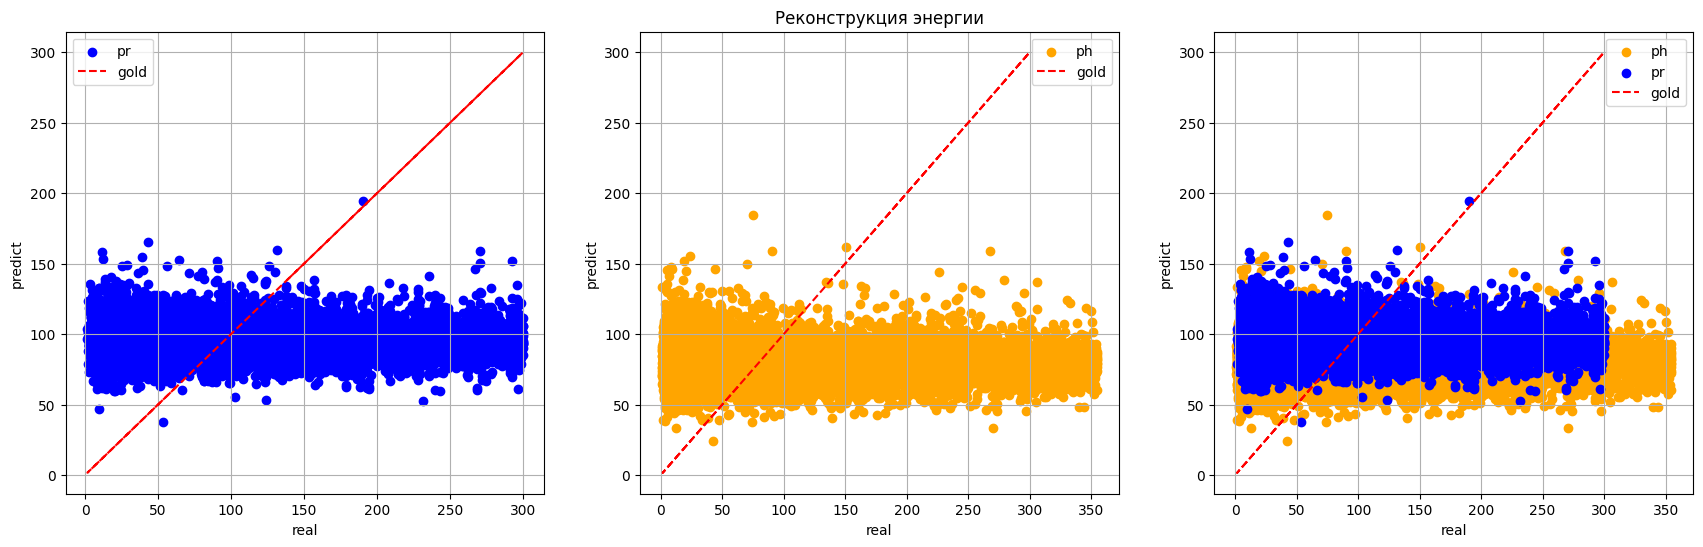

In [40]:
train_catboost_for_metric(3, name = 'Реконструкция энергии')

0:	learn: 12.8668249	total: 6.18ms	remaining: 6.17s
1:	learn: 12.8658082	total: 9.9ms	remaining: 4.94s
2:	learn: 12.8650027	total: 13.2ms	remaining: 4.4s
3:	learn: 12.8639424	total: 16.5ms	remaining: 4.1s
4:	learn: 12.8631969	total: 19.3ms	remaining: 3.85s
5:	learn: 12.8623594	total: 22.3ms	remaining: 3.69s
6:	learn: 12.8611774	total: 25.3ms	remaining: 3.59s
7:	learn: 12.8601886	total: 28.4ms	remaining: 3.52s
8:	learn: 12.8589987	total: 31.5ms	remaining: 3.47s
9:	learn: 12.8582262	total: 34.5ms	remaining: 3.41s
10:	learn: 12.8572596	total: 37.5ms	remaining: 3.37s
11:	learn: 12.8565723	total: 40.6ms	remaining: 3.34s
12:	learn: 12.8553847	total: 43.7ms	remaining: 3.32s
13:	learn: 12.8545800	total: 46.8ms	remaining: 3.3s
14:	learn: 12.8538430	total: 50ms	remaining: 3.28s
15:	learn: 12.8533019	total: 70.4ms	remaining: 4.33s
16:	learn: 12.8523126	total: 73.4ms	remaining: 4.25s
17:	learn: 12.8514149	total: 76.5ms	remaining: 4.17s
18:	learn: 12.8509530	total: 79.6ms	remaining: 4.11s
19:	learn

{'pr': {'rmse': 166.4516505292516,
  'r2': -0.014943909241967646,
  'model': <catboost.core.CatBoostRegressor at 0x7fee76150730>},
 'ph': {'rmse': 184.04457700302606,
  'r2': -0.016641582454463455,
  'model': <catboost.core.CatBoostRegressor at 0x7fee76157c10>}}

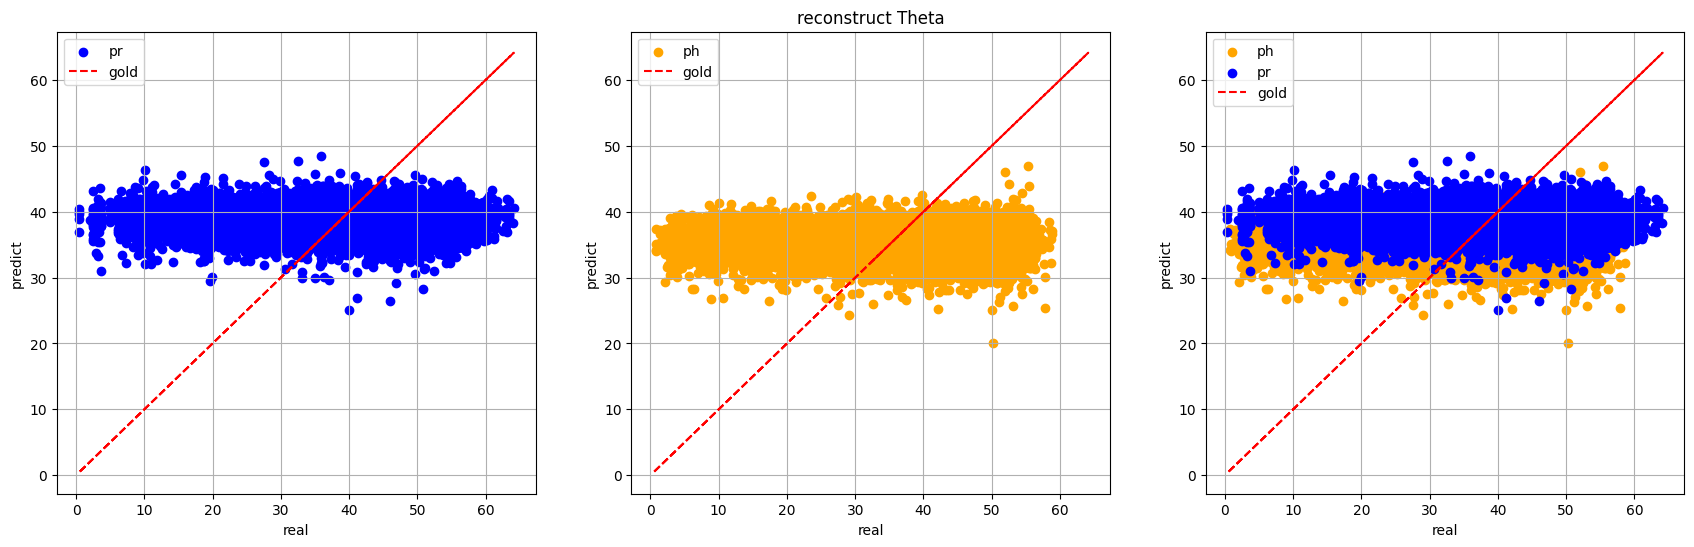

In [25]:
train_catboost_for_metric(4, name = 'reconstruct Theta')

0:	learn: 103.8759409	total: 7.48ms	remaining: 7.47s
1:	learn: 103.8692377	total: 13.6ms	remaining: 6.8s
2:	learn: 103.8643452	total: 17.7ms	remaining: 5.87s
3:	learn: 103.8561706	total: 21.8ms	remaining: 5.42s
4:	learn: 103.8510624	total: 25.1ms	remaining: 4.99s
5:	learn: 103.8427775	total: 28.1ms	remaining: 4.66s
6:	learn: 103.8367277	total: 31.2ms	remaining: 4.42s
7:	learn: 103.8284053	total: 34.1ms	remaining: 4.23s
8:	learn: 103.8192457	total: 36.8ms	remaining: 4.05s
9:	learn: 103.8132469	total: 39.5ms	remaining: 3.91s
10:	learn: 103.8060342	total: 42.1ms	remaining: 3.79s
11:	learn: 103.8030179	total: 44.8ms	remaining: 3.69s
12:	learn: 103.7950390	total: 47.4ms	remaining: 3.6s
13:	learn: 103.7890272	total: 50ms	remaining: 3.52s
14:	learn: 103.7799380	total: 52.6ms	remaining: 3.46s
15:	learn: 103.7744157	total: 55.1ms	remaining: 3.39s
16:	learn: 103.7675390	total: 57.6ms	remaining: 3.33s
17:	learn: 103.7604719	total: 60.4ms	remaining: 3.29s
18:	learn: 103.7523608	total: 62.9ms	remai

{'pr': {'rmse': 10971.317205981333,
  'r2': -0.016707299398483144,
  'model': <catboost.core.CatBoostRegressor at 0x7f090b68b670>},
 'ph': {'rmse': 10614.713645368127,
  'r2': 0.016780516591857864,
  'model': <catboost.core.CatBoostRegressor at 0x7f08e33f9b80>}}

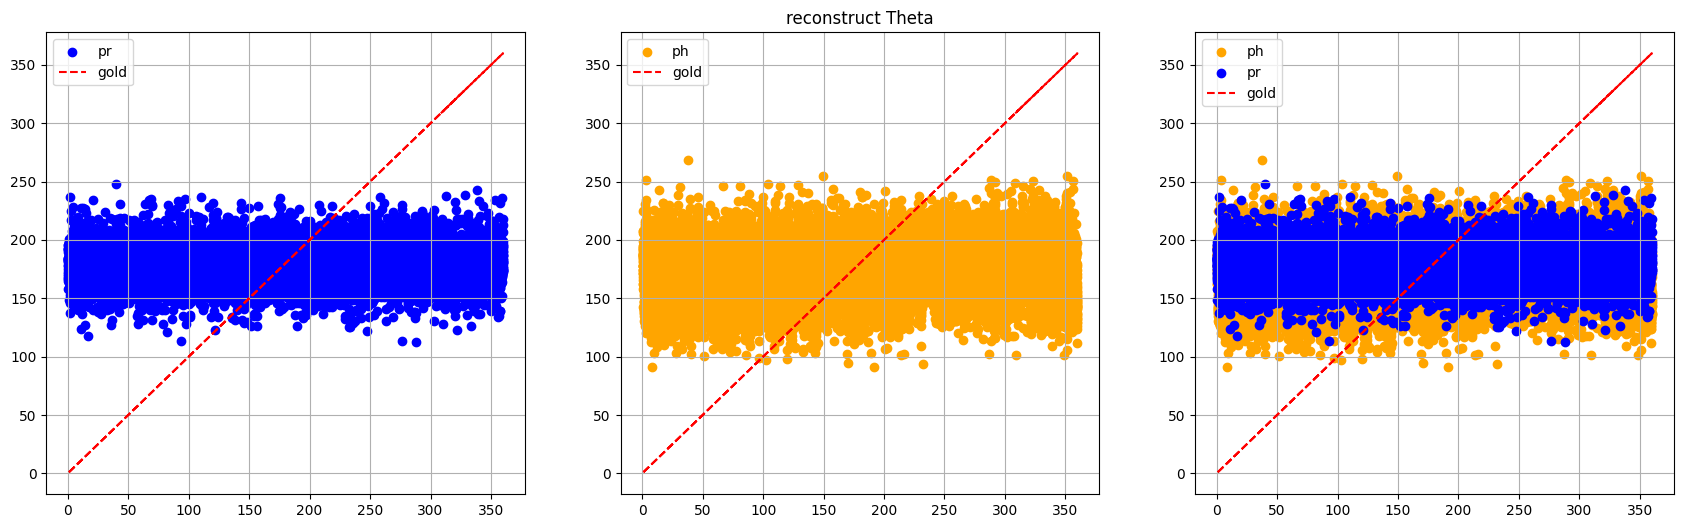

In [67]:
train_catboost_for_metric(5, name = 'reconstruct Theta')

0:	learn: 8.7486417	total: 7.08ms	remaining: 7.07s
1:	learn: 8.7276141	total: 13.5ms	remaining: 6.72s
2:	learn: 8.7101320	total: 17.7ms	remaining: 5.88s
3:	learn: 8.6955706	total: 21.7ms	remaining: 5.41s
4:	learn: 8.6814358	total: 25.3ms	remaining: 5.03s
5:	learn: 8.6699205	total: 28.5ms	remaining: 4.72s
6:	learn: 8.6601098	total: 31.4ms	remaining: 4.46s
7:	learn: 8.6511848	total: 34.4ms	remaining: 4.26s
8:	learn: 8.6438160	total: 37ms	remaining: 4.07s
9:	learn: 8.6372666	total: 39.6ms	remaining: 3.92s
10:	learn: 8.6314676	total: 42.1ms	remaining: 3.79s
11:	learn: 8.6267102	total: 44.7ms	remaining: 3.68s
12:	learn: 8.6207356	total: 47.2ms	remaining: 3.59s
13:	learn: 8.6160154	total: 49.8ms	remaining: 3.5s
14:	learn: 8.6119802	total: 52.4ms	remaining: 3.44s
15:	learn: 8.6083118	total: 55ms	remaining: 3.38s
16:	learn: 8.6048762	total: 57.5ms	remaining: 3.33s
17:	learn: 8.6017048	total: 60.2ms	remaining: 3.28s
18:	learn: 8.5988594	total: 62.7ms	remaining: 3.23s
19:	learn: 8.5960633	total:

{'pr': {'rmse': 73.64475273358056,
  'r2': 0.0372837299229688,
  'model': <catboost.core.CatBoostRegressor at 0x7f0907985220>},
 'ph': {'rmse': 436478.0243686674,
  'r2': 0.5354085522513732,
  'model': <catboost.core.CatBoostRegressor at 0x7f097ca36700>}}

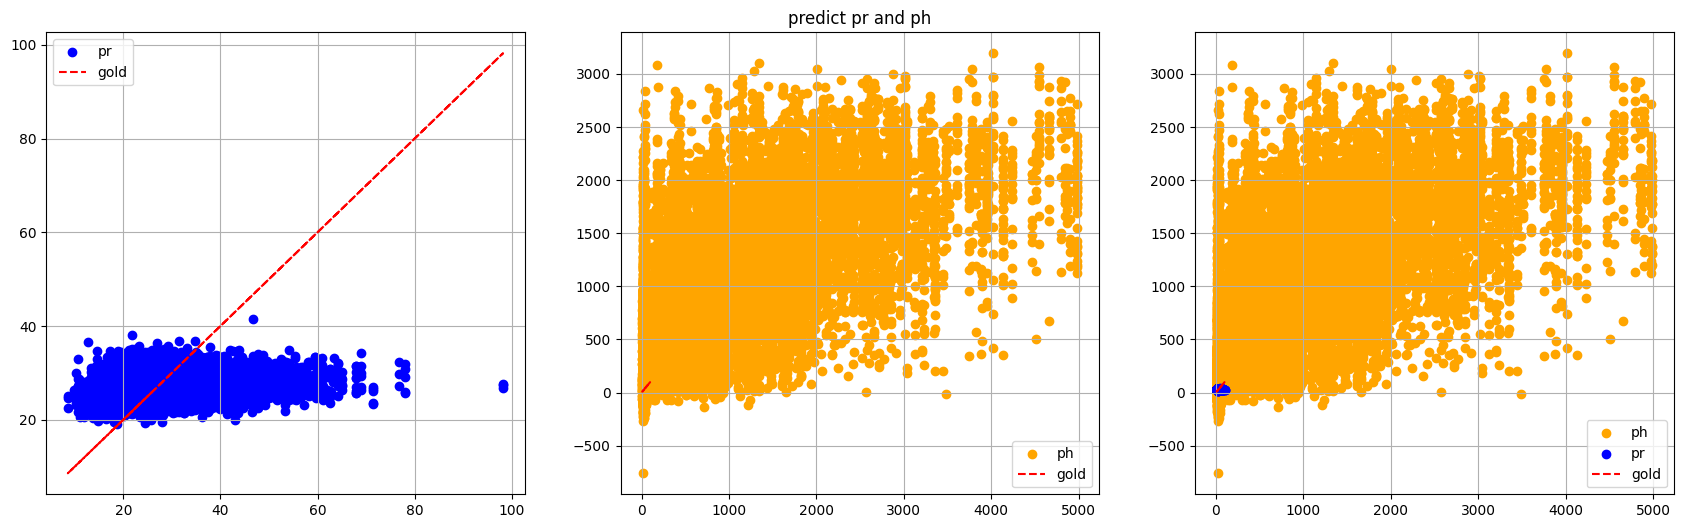

In [64]:
train_catboost_for_metric(6)